In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [117]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


There are 716164 rows in this data set, and 126392 Hurricanes in the North Atlantic

In [118]:
df[df['BASIN']=='NA'].count()

SID         126392
SEASON      126392
NUMBER      126392
BASIN       126392
SUBBASIN    126392
NAME         53334
ISO_TIME    126392
NATURE      126392
LAT         126392
LON         126392
WMO_WIND     53955
WMO_PRES     22975
dtype: int64

In [119]:
df['BASIN'].nunique()

7

In [120]:
df['SUBBASIN'].nunique()

9

In [121]:
df['NATURE'].nunique()

6

In [122]:
df = df.rename(columns={"WMO_WIND":'WIND', "WMO_PRES":'PRES'})

In [123]:
df['WIND'].nlargest(10)

666142    185.0
666140    180.0
666144    180.0
427655    165.0
178210    160.0
178211    160.0
178213    160.0
482093    160.0
552477    160.0
605764    160.0
Name: WIND, dtype: float64

In [124]:
type(df.WIND)

pandas.core.series.Series

In [125]:
df2 =df.groupby(['SID'])

In [126]:
df2.max().nlargest(10, 'WIND')

,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
SID,,,,,,,,,,,
2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-24 12:00:00,TS,23.2,-94.0000,185.0,1007.0
1980214N11330,1980,57,NA,NA,ALLEN,1980-08-11 18:00:00,TS,28.9,-30.0000,165.0,1010.0
1935241N23291,1935,46,NA,NA,NaN,1935-09-10 12:00:00,TS,57.0,-31.1196,160.0,996.0
1988253N12306,1988,74,NA,NA,GILBERT,1988-09-20 00:00:00,TS,43.4,-54.0000,160.0,1008.0
1997253N12255,1997,81,EP,MM,LINDA,1997-09-17 18:00:00,TS,23.5,-104.7000,160.0,1007.0
2005289N18282,2005,97,NA,NA,WILMA,2005-10-26 18:00:00,TS,45.5,-52.0000,160.0,1004.0
2019236N10314,2019,52,NA,NA,DORIAN,2019-09-09 00:00:00,TS,51.6,-46.4000,160.0,1011.0
1998295N12284,1998,89,NA,NA,MITCH,1998-11-09 18:00:00,TS,63.5,-5.0000,155.0,1005.0
2005261N21290,2005,80,NA,NA,RITA,2005-09-26 06:00:00,TS,39.5,-69.9000,155.0,1009.0


<Axes: xlabel='NAME'>

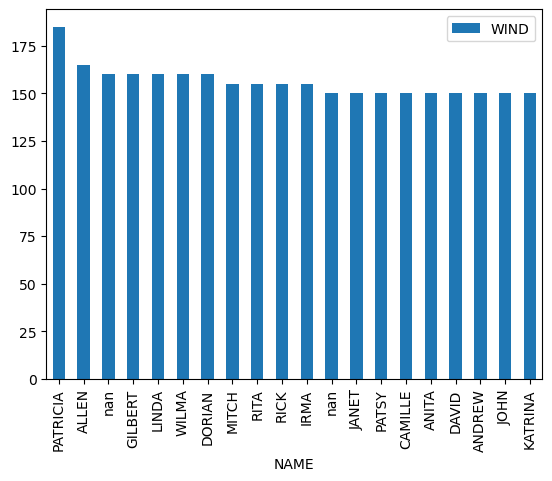

In [127]:
df2.max().nlargest(20, 'WIND').plot(kind='bar', x='NAME', y='WIND')

<Axes: xlabel='BASIN'>

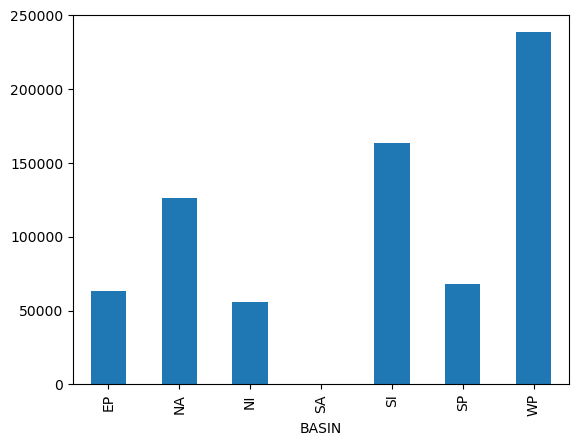

In [128]:
df3 = df.groupby(['BASIN'])
df3.BASIN.count().plot(kind = 'bar')

<Axes: xlabel='BASIN'>

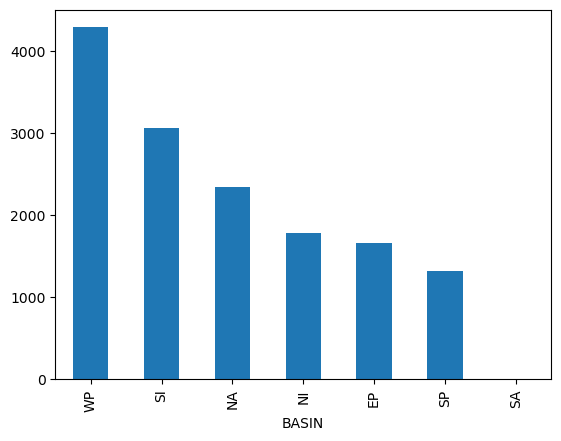

In [129]:
df3.SID.nunique().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='LON', ylabel='LAT'>

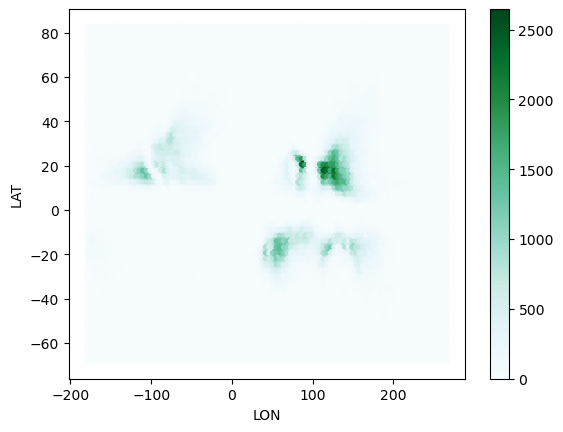

In [130]:
df.plot.hexbin('LON','LAT')

In [131]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].unique()

array(['2005236N23285'], dtype=object)

In [132]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID']

603763    2005236N23285
603764    2005236N23285
603765    2005236N23285
603766    2005236N23285
603767    2005236N23285
              ...      
603822    2005236N23285
603823    2005236N23285
603824    2005236N23285
603825    2005236N23285
603826    2005236N23285
Name: SID, Length: 64, dtype: object

<Axes: xlabel='Lattitude', ylabel='Longitude'>

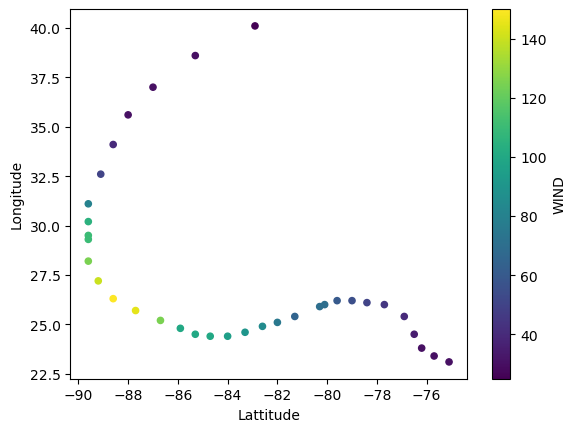

In [133]:
df[(df['SID'] == '2005236N23285')].plot.scatter(x='LON', y='LAT', c ='WIND', xlabel='Lattitude', ylabel='Longitude')


In [134]:
dfT = df.set_index('ISO_TIME')

<Axes: xlabel='ISO_TIME'>

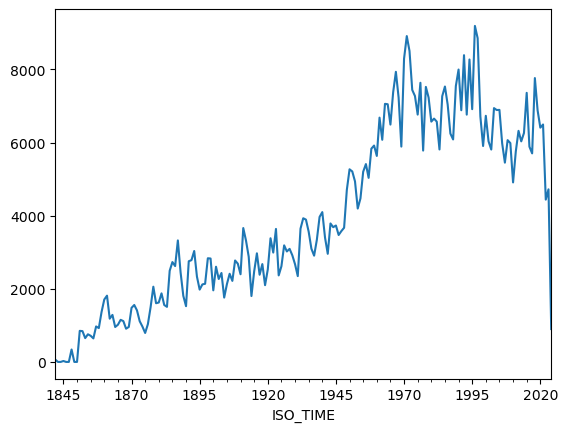

In [145]:
dfT['SID'].resample('YE').count().plot()

1970 and 1995 look like they have very high hurricane activity. The sharp drop off at the end is likely a recording issue; it is hard to tell but maybe the data was published before the season was over. The year ~2000 is low when compared to previous trends in the data as well. 